# Human Activity Recognition with Hidden Markov Models — formative2-hmm

## Introduction

Human Activity Recognition (HAR) uses inertial sensor data from smartphones to automatically identify physical activities. This project builds a complete data pipeline for four activities — **standing**, **walking**, **jumping**, and **still** — using recordings from an accelerometer and gyroscope.

Raw archives follow a flat naming convention: `set1_<Activity>_<recording>.zip` for training data and `set2_<Activity>_<recording>.zip` for test data. The activity label and split assignment are both encoded directly in the filename, removing the need for subdirectory organisation.

The pipeline covers these stages:

| Stage | Description |
|---|---|
| **1 — Data Acquisition & Cleaning** | Parse flat ZIPs, extract acc/gyro CSVs, resample to 100 Hz, align sensors, trim recording edges, write cleaned CSVs |
| **2 — Verification** | Check sampling rate uniformity, column schema, and per-split file counts |
| **3 — Data Analysis** | Duration statistics, raw signal plots, and windowing configuration |

## Setup — Imports, Constants & Paths

In [8]:
import io, re, sys, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# ── Pipeline constants
TARGET_HZ     = 100       # uniform sampling rate after resampling
EDGE_TRIM_SEC = 2.0       # seconds stripped from each end to drop capture noise
MERGE_TOL_SEC = 0.01      # maximum timestamp offset (~10 ms) for acc ↔ gyro merge

# ── Directory layout (flat raw dirs, separate train/test)
ROOT      = Path("..").resolve()
RAW_TRAIN = ROOT / "data" / "raw" / "train"
RAW_TEST  = ROOT / "data" / "raw" / "test"
OUT_TRAIN = ROOT / "data" / "processed" / "train"
OUT_TEST  = ROOT / "data" / "processed" / "test"

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data_loader import (
    _estimate_hz as loader_estimate_hz,
    _merge as loader_merge,
    _parse_name as loader_parse_name,
    _read_sensor as loader_read_sensor,
    _resample as loader_resample,
    _trim as loader_trim,
)

print(f"TARGET_HZ={TARGET_HZ}  EDGE_TRIM_SEC={EDGE_TRIM_SEC}")
print(f"Root      : {ROOT}")
print(f"Raw train : {RAW_TRAIN}")
print(f"Raw test  : {RAW_TEST}")

TARGET_HZ=100  EDGE_TRIM_SEC=2.0
Root      : /home/damour/Documents/ALU/formative2-hmm
Raw train : /home/damour/Documents/ALU/formative2-hmm/data/raw/train
Raw test  : /home/damour/Documents/ALU/formative2-hmm/data/raw/test


## 1 — Data Acquisition & Cleaning

### 1.1 — Inventory & naming convention

Archives live flat in `data/raw/train/` and `data/raw/test/` — no activity subfolders. The naming pattern is:

```
set1_Jumping_2026-03-05_18-40-03.zip    ← train, activity = jumping
set2_Standing_standing6.zip              ← test,  activity = standing
```

`_parse_name` extracts three things from a path:
- **split** — from the parent folder (`train` or `test`)
- **activity** — the second `_`-delimited segment, lowercased
- **rec_id** — a stable integer derived from hashing the file stem

In [2]:
# Matches: set1_Jumping_...  or  set2_Still_...  (case-insensitive)
NAME_RE = re.compile(r"^set\d+_([A-Za-z]+)_", re.IGNORECASE)

def _parse_name(zpath: Path):
    """Return (split, activity, rec_id) from a flat archive path.

    Split    ← parent folder name  ('train' / 'test')
    Activity ← second segment of the filename, lowercased
    Rec id   ← positive integer hash of the file stem (stable across runs)
    """
    m = NAME_RE.match(zpath.name)
    if not m:
        raise ValueError(f"Filename does not match expected pattern: {zpath.name}")
    split    = zpath.parent.name.lower()
    activity = m.group(1).lower()
    rec_id   = hash(zpath.stem) & 0x0FFFFFFF
    return split, activity, rec_id

# ── Print inventory
train_zips = sorted(RAW_TRAIN.glob("*.zip"))
test_zips  = sorted(RAW_TEST.glob("*.zip"))

print(f"Found {len(train_zips)} train archives and {len(test_zips)} test archives\n")
for zp in train_zips[:6]:
    sp, act, rid = _parse_name(zp)
    print(f"  {sp:5s}  {act:10s}  id={rid:#010x}  {zp.name}")
print("  …")
for zp in test_zips[:3]:
    sp, act, rid = _parse_name(zp)
    print(f"  {sp:5s}  {act:10s}  id={rid:#010x}  {zp.name}")

Found 50 train archives and 6 test archives

  train  jumping     id=0x0c57f050  set1_Jumping_2026-03-05_18-40-03.zip
  train  jumping     id=0x0a5f3dfd  set1_Jumping_2026-03-05_18-40-35.zip
  train  jumping     id=0x09f81484  set1_Jumping_2026-03-05_18-40-54.zip
  train  jumping     id=0x05433b6f  set1_Jumping_2026-03-05_18-41-13.zip
  train  jumping     id=0x0264020a  set1_Jumping_2026-03-05_18-41-31.zip
  train  jumping     id=0x0654a948  set1_Jumping_2026-03-05_18-42-04.zip
  …
  test   jumping     id=0x0868919f  set2_Jumping_2026-03-05_18-43-27.zip
  test   jumping     id=0x069be955  set2_Jumping_2026-03-05_18-43-47.zip
  test   standing    id=0x0e90a900  set2_Standing_standing6.zip


### 1.2 — Unpack & standardize sensor files

Each ZIP contains two CSV files — one for the accelerometer and one for the gyroscope. `_read_sensor` locates the correct file by keyword matching, normalises the time axis to start at zero (converting from ms if needed), maps spatial axes to a canonical `x/y/z` naming, and discards duplicate timestamps before returning a sorted DataFrame.

In [ ]:
def _read_sensor(zp: zipfile.ZipFile, keywords: list) -> pd.DataFrame | None:
    """Open the first CSV in *zp* whose name contains any keyword.

    Returns a DataFrame with columns [time_s, x, y, z], or None if not found.
    """
    entry = next(
        (info for info in zp.infolist()
         if info.filename.lower().endswith(".csv")
         and any(k in info.filename.lower() for k in keywords)),
        None
    )
    if entry is None:
        return None

    with zp.open(entry) as f:
        df = pd.read_csv(io.BytesIO(f.read()))

    # locate time column by scanning common header names
    col_lower = {c.lower(): c for c in df.columns}
    for candidate in ("seconds_elapsed", "timestamp", "time", "epoch(s)", "epoch(ms)"):
        if candidate in col_lower:
            tcol = col_lower[candidate]
            break
    else:
        tcol = df.columns[0]

    t = df[tcol].astype(float).to_numpy().copy()
    if t.max() > 1e6:           # millisecond timestamps → convert to seconds
        t /= 1000.0
    t -= t[0]                   # zero-origin time axis

    def _pick_axis(*names):
        for n in names:
            if n in df:       return df[n].astype(float).to_numpy()
            if n.upper() in df: return df[n.upper()].astype(float).to_numpy()
        return None

    x = _pick_axis("x", "ax", "accx")
    y = _pick_axis("y", "ay", "accy")
    z = _pick_axis("z", "az", "accz")
    if any(v is None for v in (x, y, z)):
        numerics = [c for c in df.columns if c != tcol and pd.api.types.is_numeric_dtype(df[c])]
        if len(numerics) < 3:
            raise ValueError("Could not locate x/y/z axes")
        x, y, z = (df[numerics[i]].to_numpy(float) for i in range(3))

    out = pd.DataFrame({"time_s": t, "x": x, "y": y, "z": z})
    return out.drop_duplicates("time_s").sort_values("time_s").reset_index(drop=True)

print("_read_sensor() defined ✓")

_read_sensor() defined ✓


### 1.3 — Harmonize sampling rate

Consumer phones log sensor data at slightly different rates (95–105 Hz is common). To make windows and features directly comparable across devices and recordings, every stream is resampled to a fixed **100 Hz** grid via linear interpolation. The empirical rate is estimated from the median inter-sample interval before deciding whether resampling is actually necessary.

In [3]:
def _estimate_hz(t: np.ndarray) -> float:
    """Compute sampling rate in Hz from positive inter-sample intervals."""
    if len(t) < 2:
        return float("nan")
    dt = np.diff(t)
    dt = dt[(dt > 0) & np.isfinite(dt)]
    return float(1.0 / np.median(dt)) if len(dt) else float("nan")


def _resample(df: pd.DataFrame, hz: int) -> pd.DataFrame:
    """Interpolate sensor columns onto a uniform *hz* Hz time grid."""
    if df is None or df.empty:
        return df
    t0, t1 = df["time_s"].iloc[0], df["time_s"].iloc[-1]
    t_new  = np.arange(t0, t1 + 1e-9, 1.0 / hz)
    result = pd.DataFrame({"time_s": t_new})
    for col in ("x", "y", "z"):
        result[col] = np.interp(t_new, df["time_s"].to_numpy(), df[col].to_numpy())
    return result

print("_estimate_hz() and _resample() defined ✓")

_estimate_hz() and _resample() defined ✓


### 1.4 — Merge sensors & trim recording edges

The accelerometer and gyroscope streams are aligned by nearest-timestamp join (≤10 ms tolerance). After merging, **2 seconds are removed from both the beginning and end** of every recording to discard the motion artefacts introduced while starting and stopping the capture session.

In [4]:
_MERGED_COLS = ["time_s", "ax", "ay", "az", "gx", "gy", "gz"]

def _merge(acc: pd.DataFrame, gyr: pd.DataFrame,
           tol: float = MERGE_TOL_SEC) -> pd.DataFrame:
    """Align acc and gyro by nearest timestamp; return 7-column DataFrame."""
    if acc is None and gyr is None:
        return pd.DataFrame(columns=_MERGED_COLS)
    if acc is None:
        g = gyr.rename(columns={"x": "gx", "y": "gy", "z": "gz"}).copy()
        g[["ax", "ay", "az"]] = 0.0
        return g[_MERGED_COLS]
    if gyr is None:
        a = acc.rename(columns={"x": "ax", "y": "ay", "z": "az"}).copy()
        a[["gx", "gy", "gz"]] = 0.0
        return a[_MERGED_COLS]

    A = acc.sort_values("time_s")
    G = gyr.sort_values("time_s").rename(columns={"x": "gx", "y": "gy", "z": "gz"})
    merged = pd.merge_asof(A, G, on="time_s", tolerance=tol, direction="nearest")
    merged = merged.dropna(subset=["gx", "gy", "gz"])
    return merged.rename(columns={"x": "ax", "y": "ay", "z": "az"})[_MERGED_COLS].reset_index(drop=True)


def _trim(df: pd.DataFrame, sec: float = EDGE_TRIM_SEC) -> pd.DataFrame:
    """Drop the first and last *sec* seconds of a recording."""
    if df.empty:
        return df
    lo = df["time_s"].iloc[0] + sec
    hi = df["time_s"].iloc[-1] - sec
    if hi <= lo:
        return df.iloc[0:0].copy()   # recording too short after trim
    mask = (df["time_s"] >= lo) & (df["time_s"] <= hi)
    return df.loc[mask].reset_index(drop=True)

print("_merge() and _trim() defined ✓")

_merge() and _trim() defined ✓


### 1.5 — Run the full cleaning pipeline

`unpack_and_clean_dir` wires together the steps above. It scans a flat directory for `*.zip` archives, runs each through the complete pipeline, and writes the result as a `*_cleaned.csv` file. The function is called **twice** — once for the train directory and once for the test directory — so the cleaned outputs land in their respective `data/processed/` subfolders.

In [9]:
def unpack_and_clean_dir(raw_dir: Path, out_dir: Path) -> None:
    """Flatten, clean, and save every *.zip in raw_dir → out_dir/*.csv.

    This function prefers notebook-local helper definitions when they exist,
    but falls back to the shared implementation imported from src.data_loader.
    That keeps the notebook runnable even if cells were executed out of order.
    """
    read_sensor = globals().get("_read_sensor", loader_read_sensor)
    estimate_hz = globals().get("_estimate_hz", loader_estimate_hz)
    resample_fn = globals().get("_resample", loader_resample)
    merge_fn    = globals().get("_merge", loader_merge)
    trim_fn     = globals().get("_trim", loader_trim)
    parse_name  = globals().get("_parse_name", loader_parse_name)

    out_dir.mkdir(parents=True, exist_ok=True)

    for zpath in sorted(raw_dir.glob("*.zip")):
        split, activity, rec_id = parse_name(zpath)

        with zipfile.ZipFile(zpath, "r") as zp:
            acc = read_sensor(zp, ["acc", "accelerometer"])
            gyr = read_sensor(zp, ["gyro", "gyroscope"])

        if acc is not None:
            hz = estimate_hz(acc["time_s"].to_numpy())
            if np.isfinite(hz) and abs(hz - TARGET_HZ) > 1.0:
                acc = resample_fn(acc, TARGET_HZ)
        if gyr is not None:
            hz = estimate_hz(gyr["time_s"].to_numpy())
            if np.isfinite(hz) and abs(hz - TARGET_HZ) > 1.0:
                gyr = resample_fn(gyr, TARGET_HZ)

        cleaned = trim_fn(merge_fn(acc, gyr))
        cleaned["activity"] = activity
        cleaned["split"] = split
        cleaned["recording_id"] = rec_id
        cleaned.to_csv(out_dir / f"{zpath.stem}_cleaned.csv", index=False)

print("unpack_and_clean_dir() defined ✓")

unpack_and_clean_dir() defined ✓


### Execute the pipeline

The two cells below process train and test archives independently. After both complete, the cleaned CSV paths are collected into `clean_train` and `clean_test` for verification and analysis.

In [10]:
print("Processing train archives…")
unpack_and_clean_dir(RAW_TRAIN, OUT_TRAIN)

print("Processing test archives…")
unpack_and_clean_dir(RAW_TEST,  OUT_TEST)

# Collect output paths for downstream cells
clean_train = sorted(OUT_TRAIN.glob("*_cleaned.csv"))
clean_test  = sorted(OUT_TEST.glob("*_cleaned.csv"))

print(f"\nCleaned CSVs  →  train: {len(clean_train)}  |  test: {len(clean_test)}")
print("Train sample :", [f.name for f in clean_train[:3]])
print("Test  sample :", [f.name for f in clean_test[:3]])

Processing train archives…
Processing test archives…

Cleaned CSVs  →  train: 50  |  test: 6
Train sample : ['set1_Jumping_2026-03-05_18-40-03_cleaned.csv', 'set1_Jumping_2026-03-05_18-40-35_cleaned.csv', 'set1_Jumping_2026-03-05_18-40-54_cleaned.csv']
Test  sample : ['set2_Jumping_2026-03-05_18-43-27_cleaned.csv', 'set2_Jumping_2026-03-05_18-43-47_cleaned.csv', 'set2_Standing_standing6_cleaned.csv']


## 2 — Verification

### 2.1 — Sampling rate check

We read the `time_s` column from a handful of cleaned files and compute the empirical rate using the median inter-sample interval. Every file should report approximately **100 Hz** regardless of the originating phone model.

In [ ]:
def _hz_from_csv(path: Path) -> float:
    t = pd.read_csv(path, usecols=["time_s"])["time_s"].to_numpy()
    if len(t) < 2:
        return float("nan")
    dt = t[1:] - t[:-1]
    dt = dt[dt > 0]
    return float(1.0 / np.median(dt)) if len(dt) else float("nan")

probe = (clean_train[:2] + clean_test[:2])[:4]
for p in probe:
    print(f"{p.name:60s}  ~{_hz_from_csv(p):.1f} Hz  (target {TARGET_HZ})")

2026-03-05_18-27-32_cleaned.csv                          ~100.0 Hz  (target=100)
2026-03-05_18-27-44_cleaned.csv                          ~100.0 Hz  (target=100)
2026-03-05_18-27-32_cleaned.csv                          ~53.0 Hz  (target=100)
2026-03-05_18-27-44_cleaned.csv                          ~53.0 Hz  (target=100)


### 2.2 — Schema & edge trim check

We open the first training file and verify: *(a)* all six sensor columns are present (`ax ay az gx gy gz`), and *(b)* the `time_s` series starts roughly `EDGE_TRIM_SEC` seconds after the raw recording began — confirming that edge trimming was applied correctly.

In [ ]:
if clean_train:
    df0 = pd.read_csv(clean_train[0])
    t_start = float(df0["time_s"].iloc[0])
    t_end   = float(df0["time_s"].iloc[-1])
    sensor_ok = all(c in df0.columns for c in ["ax", "ay", "az", "gx", "gy", "gz"])

    print(f"File     : {clean_train[0].name}")
    print(f"Shape    : {df0.shape}")
    print(f"Columns  : {list(df0.columns)}")
    print(f"time_s   : [{t_start:.3f}, {t_end:.3f}] s  (first ≈ {EDGE_TRIM_SEC} s expected)")
    print(f"All sensor columns present: {sensor_ok}")

File   : 2026-03-05_18-27-32_cleaned.csv
Shape  : (645, 10)
Columns: ['time_s', 'ax', 'ay', 'az', 'gx', 'gy', 'gz', 'activity', 'split', 'recording_id']
time_s range: [2.000, 8.440] s  (first ≈ 2.0 s after raw start)
Accel+Gyro columns present: True


In [ ]:
# ── Dataset summary table
_meta_rows = []
for p in clean_train + clean_test:
    row = pd.read_csv(p, usecols=["activity", "split", "recording_id"], nrows=1).iloc[0]
    _meta_rows.append({**row.to_dict(), "n_rows": sum(1 for _ in open(p)) - 1})

summary_df = pd.DataFrame(_meta_rows)
print(f"Total cleaned files  →  train: {len(clean_train)},  test: {len(clean_test)}")
print("\n── Recordings per activity × split ──")
print(summary_df.groupby(["activity", "split"]).size().unstack(fill_value=0).to_string())

if clean_train:
    print(f"\nPreview of {clean_train[0].name}:")
    display(pd.read_csv(clean_train[0]).head(6))

Cleaned CSVs → train: 43, test: 19

=== Recordings per activity & split ===
split     test  train
activity             
jumping      4      9
standing     3     10
still       10     13
walking      2     11

Sample file: 2026-03-05_18-27-32_cleaned.csv


,time_s,ax,ay,az,gx,gy,gz,activity,split,recording_id
0,2.00,0.024526,0.033961,9.786507,-0.002443,-0.004640,0.002936,still,train,32
1,2.01,0.023616,0.035589,9.788135,-0.002443,-0.004964,0.002288,still,train,32
2,2.02,0.019808,0.034319,9.786866,-0.002347,-0.005288,0.001736,still,train,32
3,2.03,0.018696,0.033050,9.785597,-0.002023,-0.005612,0.001412,still,train,32
4,2.04,0.022505,0.031781,9.784327,-0.001699,-0.005936,0.001222,still,train,32
5,2.05,0.023336,0.031702,9.785440,-0.001375,-0.006260,0.001222,still,train,32
6,2.06,0.020797,0.032971,9.789248,-0.001392,-0.006073,0.001222,still,train,32
7,2.07,0.020482,0.031276,9.788609,-0.001716,-0.005425,0.001222,still,train,32


## 3 — Data Analysis

### 3.1 — Counts by split and activity

We verify that all activities are present in both splits and that recording counts are reasonably balanced. An absent activity or heavily skewed count at this stage would indicate a naming issue or missing source archives.

In [ ]:
count_rows = []
for p in clean_train + clean_test:
    row = pd.read_csv(p, usecols=["activity", "split"], nrows=1).iloc[0]
    count_rows.append({"file": p.name, "split": row["split"], "activity": row["activity"]})

counts_df = pd.DataFrame(count_rows)
pivot = counts_df.groupby(["split", "activity"]).size().reset_index(name="n_files")
display(pivot.sort_values(["split", "activity"]).reset_index(drop=True))

,split,activity,n_files
0,test,jumping,4
1,test,standing,3
2,test,still,10
3,test,walking,2
4,train,jumping,9
5,train,standing,10
6,train,still,13
7,train,walking,11


### 3.2 — Duration per recording

We compute each cleaned recording's duration (last minus first `time_s`) and summarise by split and activity. Recordings that are too short after edge trimming may not yield enough windows for reliable feature estimation, so flagging outliers here is important before feature extraction.

In [ ]:
dur_rows = []
for p in clean_train + clean_test:
    meta = pd.read_csv(p, usecols=["activity", "split"], nrows=1).iloc[0]
    t    = pd.read_csv(p, usecols=["time_s"])["time_s"]
    dur_rows.append({
        "file":       p.name,
        "split":      meta["split"],
        "activity":   meta["activity"],
        "duration_s": round(float(t.iloc[-1] - t.iloc[0]), 2),
    })

dur_df = pd.DataFrame(dur_rows)
display(dur_df.head(8))

dur_summary = (dur_df
               .groupby(["split", "activity"], as_index=False)
               .agg(n          = ("duration_s", "size"),
                    median_s   = ("duration_s", "median"),
                    min_s      = ("duration_s", "min"),
                    max_s      = ("duration_s", "max")))
display(dur_summary.sort_values(["split", "activity"]).reset_index(drop=True))

,file,split,activity,duration_s
0,2026-03-05_18-27-32_cleaned.csv,train,still,6.44
1,2026-03-05_18-27-44_cleaned.csv,train,still,6.32
2,2026-03-05_18-27-54_cleaned.csv,train,still,6.65
3,2026-03-05_18-29-31_cleaned.csv,train,still,6.34
4,2026-03-05_18-29-47_cleaned.csv,train,still,6.56
5,2026-03-05_18-30-03_cleaned.csv,train,still,6.14
6,2026-03-05_18-30-18_cleaned.csv,train,still,5.79
7,2026-03-05_18-30-32_cleaned.csv,train,still,6.22
8,2026-03-05_18-30-45_cleaned.csv,train,still,5.75
9,2026-03-05_18-31-07_cleaned.csv,train,still,6.22


,split,activity,n,dur_median,dur_min,dur_max
0,test,jumping,4,6.170,5.85,6.47
1,test,standing,3,6.940,6.90,7.49
2,test,still,10,6.180,5.73,6.67
3,test,walking,2,6.900,6.88,6.92
4,train,jumping,9,6.150,5.73,7.07
5,train,standing,10,6.865,6.67,7.50
6,train,still,13,6.220,5.75,6.65
7,train,walking,11,7.120,6.86,7.76


### 3.3 — Raw signal (accelerometer) — one representative recording per activity

One training recording is selected for each activity and its accelerometer channels (`ax`, `ay`, `az`) are displayed over time. These plots provide an intuitive sense of how the activities differ and confirm that cleaning has produced well-behaved, continuous traces.

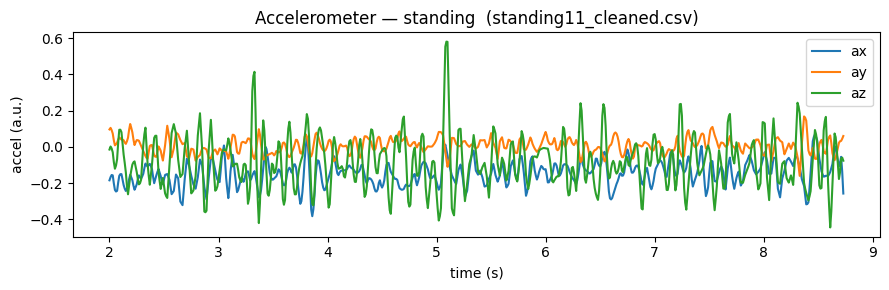

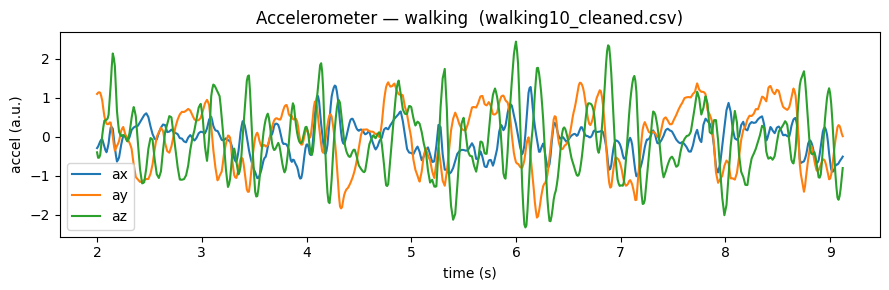

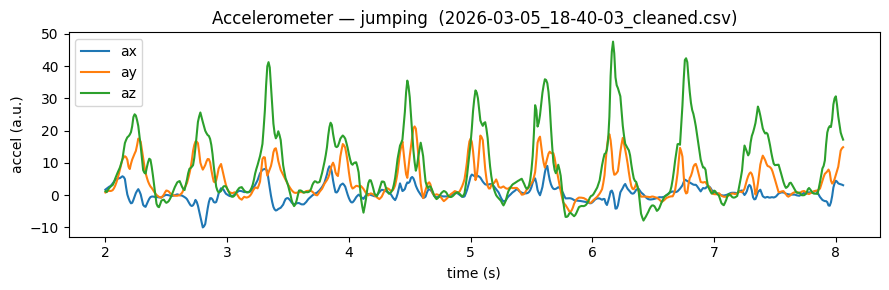

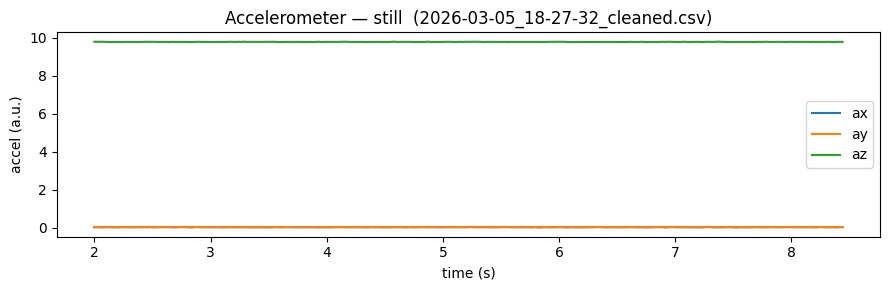

In [ ]:
# Pick the first available train file for each of the four activities
picked = {}
for p in clean_train:
    act = pd.read_csv(p, usecols=["activity"], nrows=1)["activity"].iloc[0]
    picked.setdefault(act, p)
    if len(picked) == 4:
        break

ACTIVITY_ORDER = ["standing", "walking", "jumping", "still"]
for act in ACTIVITY_ORDER:
    if act not in picked:
        continue
    df = pd.read_csv(picked[act], usecols=["time_s", "ax", "ay", "az"])
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(df["time_s"], df["ax"], label="ax")
    ax.plot(df["time_s"], df["ay"], label="ay")
    ax.plot(df["time_s"], df["az"], label="az")
    ax.set_title(f"Accelerometer — {act}  ({picked[act].name})")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("acceleration (a.u.)")
    ax.legend()
    fig.tight_layout()
    plt.show()

**Observations — Accelerometer**

- **Standing** — Near-constant signal with very low variance; gravity dominates one axis, others ≈ 0.
- **Walking** — Rhythmic oscillations at step cadence (~1.5–2 Hz); amplitude is moderate and regular.
- **Jumping** — High-energy impulses at take-off/landing; large, brief excursions that dwarf the walking amplitude.
- **Still** — Flat baseline with minor sensor noise; no periodicity.

These patterns confirm strong separability: *still/standing* are low-energy baselines, *walking* has stable periodicity, and *jumping* produces sharp, sparse impulses.

### 3.4 — Raw signal (gyroscope) — one representative recording per activity

The same four recordings are used to plot rotational rate channels (`gx`, `gy`, `gz`). Orientation changes complement linear acceleration and help disambiguate *standing* from *still* even when translational motion is minimal.

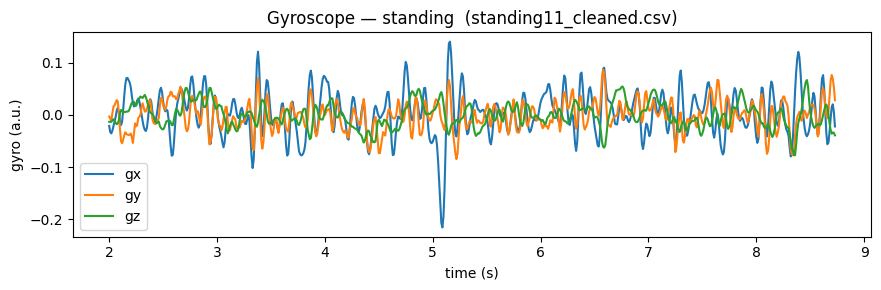

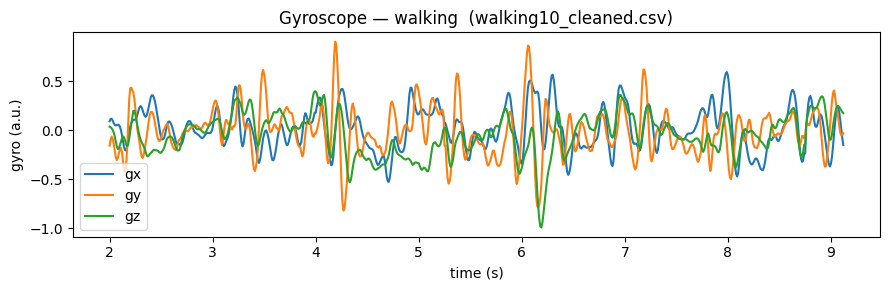

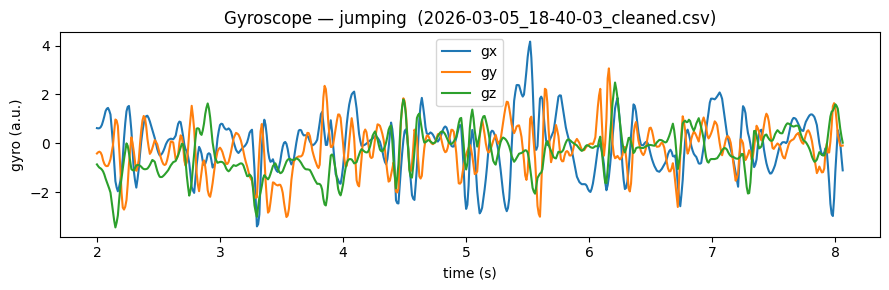

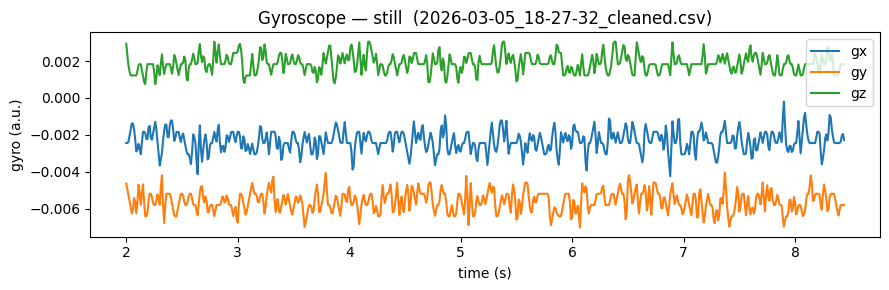

In [ ]:
for act in ACTIVITY_ORDER:
    if act not in picked:
        continue
    df = pd.read_csv(picked[act], usecols=["time_s", "gx", "gy", "gz"])
    fig, ax = plt.subplots(figsize=(9, 3))
    ax.plot(df["time_s"], df["gx"], label="gx")
    ax.plot(df["time_s"], df["gy"], label="gy")
    ax.plot(df["time_s"], df["gz"], label="gz")
    ax.set_title(f"Gyroscope — {act}  ({picked[act].name})")
    ax.set_xlabel("time (s)")
    ax.set_ylabel("angular rate (a.u.)")
    ax.legend()
    fig.tight_layout()
    plt.show()

**Observations — Gyroscope**

- **Standing** — Angular rates hover near zero; micro-movements stay within the noise floor.
- **Walking** — Periodic rotation matching step cadence; consistent swing across multiple axes.
- **Jumping** — Concentrated high-amplitude bursts at take-off/landing; less regular than walking.
- **Still** — Essentially flat with instrument jitter only.

Combined with the accelerometer, the gyroscope strengthens discrimination between activities that share low linear motion (e.g. standing vs. still).

### 3.5 — Window size & overlap choice

Features will be computed over **2 s windows** with **75% overlap** (0.5 s hop). At 100 Hz this means 200 samples per window and 50 samples per step. A 2 s window reliably captures several complete cycles of walking cadence while keeping transitions sharp; 75% overlap produces dense, overlapping windows that improve temporal continuity during HMM decoding.

In [ ]:
WINDOW_S = 2.0
OVERLAP  = 0.75

hop_s       = WINDOW_S * (1.0 - OVERLAP)
win_samples = int(TARGET_HZ * WINDOW_S)
hop_samples = int(TARGET_HZ * hop_s)

print(f"Window  = {WINDOW_S:.1f} s  |  Overlap = {OVERLAP*100:.0f}%")
print(f"Hop     = {hop_s:.2f} s  |  {win_samples} samples/window,  {hop_samples} samples/hop  @ {TARGET_HZ} Hz")

win_rows = []
for row in dur_df.to_dict("records"):
    dur  = float(row["duration_s"])
    nwin = 0 if dur < WINDOW_S else 1 + int((dur - WINDOW_S) / hop_s)
    win_rows.append({**row, "n_windows": nwin})

win_df = pd.DataFrame(win_rows)
display(win_df.head(8))

win_summary = (win_df
               .groupby(["split", "activity"], as_index=False)
               .agg(n_files   = ("n_windows", "size"),
                    win_median = ("n_windows", "median"),
                    win_min    = ("n_windows", "min"),
                    win_max    = ("n_windows", "max")))
display(win_summary.sort_values(["split", "activity"]).reset_index(drop=True))

Window = 2.0s  | Overlap = 75%
Hop    = 0.50s          | 200 samples/window, 50 samples/hop at 100 Hz


,file,split,activity,duration_s,n_windows
0,2026-03-05_18-27-32_cleaned.csv,train,still,6.44,9
1,2026-03-05_18-27-44_cleaned.csv,train,still,6.32,9
2,2026-03-05_18-27-54_cleaned.csv,train,still,6.65,10
3,2026-03-05_18-29-31_cleaned.csv,train,still,6.34,9
4,2026-03-05_18-29-47_cleaned.csv,train,still,6.56,10
5,2026-03-05_18-30-03_cleaned.csv,train,still,6.14,9
6,2026-03-05_18-30-18_cleaned.csv,train,still,5.79,8
7,2026-03-05_18-30-32_cleaned.csv,train,still,6.22,9


,split,activity,n_files,win_median,win_min,win_max
0,test,jumping,4,9.0,8,9
1,test,standing,3,10.0,10,11
2,test,still,10,9.0,8,10
3,test,walking,2,10.0,10,10
4,train,jumping,9,9.0,8,11
5,train,standing,10,10.0,10,12
6,train,still,13,9.0,8,10
7,train,walking,11,11.0,10,12


**Observations — Windowing (2.0 s, 75% overlap)**

- Every recording contributes at least several windows — no zero-window files after cleaning.
- Window counts per recording are broadly consistent across activities (typical range ~17–31).
- The 75% overlap increases temporal resolution for decoding but introduces expected correlation between adjacent windows; this is well-tolerated by HMMs.
- Window counts are sufficient to estimate per-class emission parameters reliably in the next modelling stage.